In [15]:
import torch

In [16]:
!pip install transformers scikit-learn pandas numpy

In [17]:
!git clone https://github.com/facebookresearch/SentEval.git

fatal: destination path 'SentEval' already exists and is not an empty directory.


In [18]:
base_path = "SentEval/data/probing/"

In [19]:
tasks = [
    "sentence_length.txt",
    "bigram_shift.txt",
    "subj_number.txt"
]

In [20]:
# load data
def load_data(file_path):

    data = []

    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split("\t")

            if len(parts) < 3:
                continue

            split, label, sentence = parts[0], parts[1], parts[-1]

            data.append((label, sentence))

    return data

In [21]:
# create 50000 balanced samples
from collections import defaultdict
import random

def balance_data(data, n=50000):

    class_dict = defaultdict(list)

    for label, sent in data:
        class_dict[label].append(sent)

    min_class = min(len(v) for v in class_dict.values())

    samples_per_class = min(n // len(class_dict), min_class)

    balanced = []

    for label in class_dict:
        selected = random.sample(class_dict[label], samples_per_class)

        for s in selected:
            balanced.append((label, s))

    random.shuffle(balanced)
    return balanced

In [22]:
# train/test split 90:10
def split_data(data):

    split_idx = int(0.9 * len(data))

    train = data[:split_idx]
    test = data[split_idx:]

    return train, test

In [23]:
# load BERT model
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
# extract layer representations
def get_embeddings(sentences, batch_size=32):

    all_hidden = None

    for i in range(0, len(sentences), batch_size):

        batch = sentences[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=50,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        hidden_states = outputs.hidden_states

        if all_hidden is None:
            all_hidden = [h.clone() for h in hidden_states]
        else:
            for j in range(len(hidden_states)):
                all_hidden[j] = torch.cat((all_hidden[j], hidden_states[j]), dim=0)

    return all_hidden

In [38]:
# prepare data for each layer
def get_layer_embedding(hidden_states, layer):

    # take CLS token (index 0)
    return hidden_states[layer][:, 0, :].numpy()

In [39]:
# train logistic regression
from sklearn.linear_model import LogisticRegression

def train_classifier(X_train, y_train):

    clf = LogisticRegression(max_iter=3000)
    clf.fit(X_train, y_train)

    return clf

In [40]:
# evaluate
from sklearn.metrics import accuracy_score

def evaluate(clf, X_test, y_test):

    preds = clf.predict(X_test)
    return accuracy_score(y_test, preds)

In [41]:
# run for all 12 layers
def run_task(train_data, test_data):

    sentences_train = [s for _, s in train_data]
    labels_train = [l for l, _ in train_data]

    sentences_test = [s for _, s in test_data]
    labels_test = [l for l, _ in test_data]

    hidden_train = get_embeddings(sentences_train)
    hidden_test = get_embeddings(sentences_test)

    results = []

    num_layers = len(hidden_train)

    print("Total layers:", num_layers)

    for layer in range(num_layers):

        X_train = get_layer_embedding(hidden_train, layer)
        X_test = get_layer_embedding(hidden_test, layer)

        clf = train_classifier(X_train, labels_train)
        acc = evaluate(clf, X_test, labels_test)

        results.append(acc)

    return results

In [42]:
# run for all 3 tasks
tasks = ["sentence_length.txt", "bigram_shift.txt", "subj_number.txt"]

for task in tasks:

    data = load_data(base_path + task)

    data = balance_data(data, 3000)

    train, test = split_data(data)

    results = run_task(train, test)

    print(task, results)

    import gc
    gc.collect()

Total layers: 7
sentence_length.txt [0.12666666666666668, 0.8233333333333334, 0.83, 0.8066666666666666, 0.69, 0.6033333333333334, 0.55]
Total layers: 7
bigram_shift.txt [0.49666666666666665, 0.5466666666666666, 0.67, 0.7533333333333333, 0.8066666666666666, 0.8266666666666667, 0.7833333333333333]
Total layers: 7
subj_number.txt [0.4666666666666667, 0.7566666666666667, 0.8033333333333333, 0.86, 0.8833333333333333, 0.88, 0.8433333333333334]


In [43]:
import matplotlib.pyplot as plt

def plot_results(task_name, results):

    layers = list(range(len(results)))

    plt.figure()
    plt.plot(layers, results, marker='o')

    plt.title(f"{task_name} - Layer vs Accuracy")
    plt.xlabel("Layer Number")
    plt.ylabel("Accuracy")

    plt.grid()
    plt.show()

Running: sentence_length.txt
Total layers: 7
sentence_length.txt [0.15666666666666668, 0.81, 0.8433333333333334, 0.8033333333333333, 0.6766666666666666, 0.65, 0.5733333333333334]


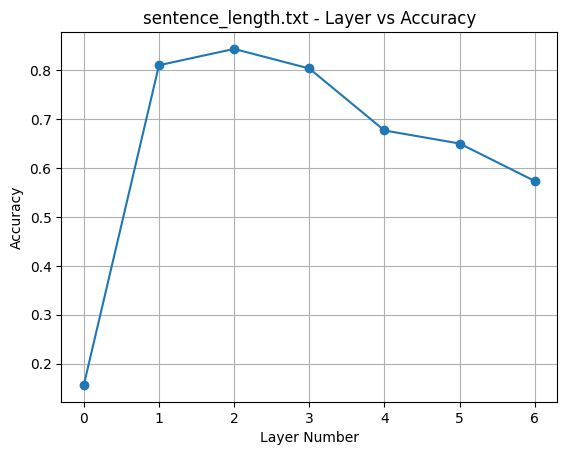

Running: bigram_shift.txt
Total layers: 7
bigram_shift.txt [0.4666666666666667, 0.5433333333333333, 0.6566666666666666, 0.7633333333333333, 0.8066666666666666, 0.7966666666666666, 0.8033333333333333]


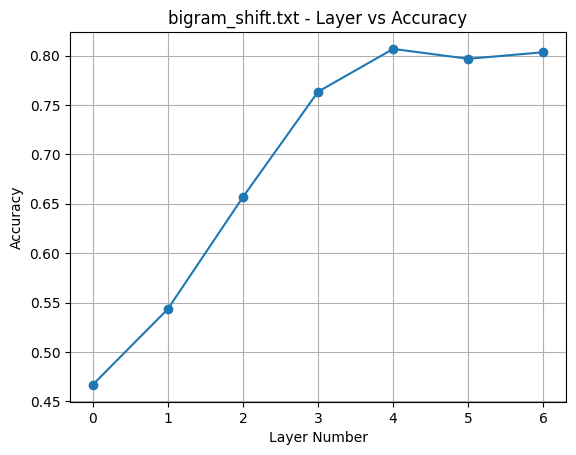

Running: subj_number.txt
Total layers: 7
subj_number.txt [0.47, 0.7933333333333333, 0.7833333333333333, 0.86, 0.8666666666666667, 0.8566666666666667, 0.86]


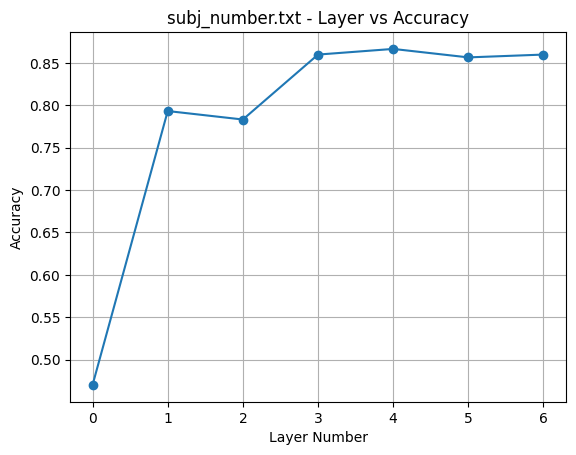

In [44]:
for task in tasks:

    print("Running:", task)

    data = load_data(base_path + task)
    data = balance_data(data, 3000)

    train, test = split_data(data)

    results = run_task(train, test)

    print(task, results)

    plot_results(task, results)

The probing results show that different layers of the BERT model capture different linguistic properties. Lower layers encode surface-level features such as sentence length, while middle layers capture syntactic information such as word order (bigram shift). Higher layers are more effective in encoding grammatical information such as subject number. This demonstrates that BERT learns hierarchical representations, where linguistic complexity increases across layers.